# Biometric keypoint detection & feature extraction with Python

## Objectifs
- Observer l'extraction de landmarks de visage, de points d'intérêt sur empreintes et de caractéristiques acoustiques sur voix.
- Construire un pipeline par lot (par dossier) et exporter les descripteurs en CSV (`outputs/`).

## Données (aucune donnée biométrique personnelle)
- **Visages** : LFW (Labeled Faces in the Wild), jeu public, 40 images.
- **Empreintes** : images **synthétiques** (motifs de crêtes générés par `prepare_fingerprint.py`).
- **Voix** : Free Spoken Digit Dataset (FSDD), licence CC BY-SA 4.0, 60 enregistrements WAV.

## Références
- MediaPipe Face Landmarker (Google), modèle `face_landmarker.task`, licence Apache 2.0.
- OpenCV : ORB (Rublee et al., 2011), CLAHE.
- librosa : MFCC, descripteurs spectraux, pYIN (Mauch & Dixon, 2014).
- Huang et al., *Labeled Faces in the Wild*, 2007.
- Jackson et al., *Free Spoken Digit Dataset*.

## 1. Imports, chemins et fonctions utilitaires

In [1]:
import os, glob, warnings
import numpy as np, pandas as pd, cv2
import librosa, librosa.display
import mediapipe as mp
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

DATA, OUT = "data", "outputs"
os.makedirs(OUT, exist_ok=True)          # dossier de sortie des CSV
IMG_EXT = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif")

def list_files(folder, patterns):
    """Liste triée des fichiers d'un dossier correspondant aux motifs donnés."""
    files = []
    for p in patterns:
        files += glob.glob(os.path.join(folder, p))
    return sorted(files)

for d in ("faces", "fingerprint", "voices"):
    print(d, ":", len(list_files(f"{DATA}/{d}", IMG_EXT + ("*.wav",))), "fichiers")

faces : 40 fichiers
fingerprint : 30 fichiers
voices : 60 fichiers


## 2. Visages : landmarks MediaPipe (FaceLandmarker)
**Choix et hypothèses** : un seul visage par image (`num_faces=1`). Normalisation : coordonnées en pixels, centrage sur le bout du nez, division par la distance inter-oculaire (coins externes des yeux). Les descripteurs sont donc invariants à la translation et à l'échelle.
**Limites** : pas d'invariance à la rotation de la tête ; les images LFW sont petites (agrandies x3 avant détection).

In [2]:
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

# Indices des points clés dans le maillage de 478 points
KEY = {"nose":1, "chin":152, "eye_r_out":33, "eye_l_out":263,
       "eye_r_in":133, "eye_l_in":362, "mouth_r":61, "mouth_l":291,
       "brow_r":105, "brow_l":334, "forehead":10}

options = vision.FaceLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path="models/face_landmarker.task"),
    running_mode=vision.RunningMode.IMAGE, num_faces=1)

rows, example_face = [], None
with vision.FaceLandmarker.create_from_options(options) as fm:
    for path in list_files(f"{DATA}/faces", IMG_EXT):
        try:
            img = cv2.imread(path)
            if img is None:
                raise ValueError("image illisible")
            h, w = img.shape[:2]
            rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            res = fm.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb))
            if not res.face_landmarks:
                raise ValueError("aucun visage détecté")
            lm = np.array([[p.x * w, p.y * h] for p in res.face_landmarks[0]])
            iod = np.linalg.norm(lm[KEY["eye_r_out"]] - lm[KEY["eye_l_out"]])
            norm = (lm - lm[KEY["nose"]]) / iod     # normalisation translation + échelle
            row = {"file": os.path.basename(path), "n_landmarks": len(lm), "iod_px": iod}
            for name, idx in KEY.items():
                row[f"{name}_x"], row[f"{name}_y"] = norm[idx]
            row["mouth_width"] = np.linalg.norm(norm[KEY["mouth_r"]] - norm[KEY["mouth_l"]])
            row["face_height"] = np.linalg.norm(norm[KEY["forehead"]] - norm[KEY["chin"]])
            row["status"] = "ok"
            if example_face is None:
                example_face = (rgb, lm)
        except Exception as e:                       # on garde la trace de l'erreur et on continue
            row = {"file": os.path.basename(path), "status": f"erreur: {e}"}
        rows.append(row)

df_faces = pd.DataFrame(rows)
df_faces.to_csv(f"{OUT}/features_faces.csv", index=False)
print(df_faces["status"].value_counts())
df_faces.head()

W0000 00:00:1791058653.771326  220164 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1791058653.821716  220176 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791058653.897539  220176 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


status
ok    40
Name: count, dtype: int64


,file,n_landmarks,iod_px,nose_x,nose_y,chin_x,chin_y,eye_r_out_x,eye_r_out_y,eye_l_out_x,...,mouth_l_y,brow_r_x,brow_r_y,brow_l_x,brow_l_y,forehead_x,forehead_y,mouth_width,face_height,status
0,face_000.jpg,478,186.392706,0.0,0.0,0.167172,0.733198,-0.329382,-0.532518,0.670393,...,0.285442,-0.357560,-0.780381,0.570525,-0.760873,0.062915,-1.117312,0.493318,1.853445,ok
1,face_001.jpg,478,176.140902,0.0,0.0,0.052611,0.947963,-0.480090,-0.409753,0.518361,...,0.325836,-0.504223,-0.676722,0.502599,-0.721470,-0.028231,-1.011662,0.793230,1.961292,ok
2,face_002.jpg,478,158.200544,0.0,0.0,0.124955,0.915276,-0.480079,-0.416914,0.514466,...,0.292158,-0.495043,-0.673529,0.439428,-0.781127,-0.078006,-1.093988,0.691217,2.019488,ok
3,face_003.jpg,478,159.831885,0.0,0.0,0.058749,0.841059,-0.481305,-0.470853,0.517040,...,0.308223,-0.483241,-0.736102,0.473387,-0.772135,-0.023274,-1.093178,0.504571,1.935975,ok
4,face_004.jpg,478,168.280844,0.0,0.0,-0.032493,0.910380,-0.657490,-0.463911,0.341021,...,0.267768,-0.622623,-0.737816,0.337584,-0.779819,-0.133420,-1.110629,0.693988,2.023528,ok


## Empreintes : points d'intérêt ORB
**Choix** : redimensionnement 256x256, CLAHE, ORB (500 points max).
**Limite** : ORB détecte des points d'intérêt, pas des minuties au sens strict (terminaisons, bifurcations). Empreintes synthétiques.

In [3]:
orb = cv2.ORB_create(nfeatures=500)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
rows, example_fp = [], None
for path in list_files(f"{DATA}/fingerprint", IMG_EXT):
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError("image illisible")
        img = cv2.resize(img, (256, 256))           # taille normalisée
        img = clahe.apply(img)                       # contraste local
        kps, des = orb.detectAndCompute(img, None)
        n = len(kps)
        pts = np.array([k.pt for k in kps]) / 256.0 if n else np.zeros((0, 2))
        rows.append({
            "file": os.path.basename(path),
            "n_keypoints": n,
            "kp_density": n / (256 * 256),
            "resp_mean": float(np.mean([k.response for k in kps])) if n else 0.0,
            "size_mean": float(np.mean([k.size for k in kps])) if n else 0.0,
            "x_mean": pts[:, 0].mean() if n else np.nan,
            "y_mean": pts[:, 1].mean() if n else np.nan,
            "x_std":  pts[:, 0].std()  if n else np.nan,
            "y_std":  pts[:, 1].std()  if n else np.nan,
            "desc_bit_mean": np.unpackbits(des, axis=1).mean() if n else np.nan,
            "contrast_std": img.std() / 255.0,
            "status": "ok"})
        if example_fp is None:
            example_fp = (img, kps)
    except Exception as e:
        rows.append({"file": os.path.basename(path), "status": f"erreur: {e}"})

df_fp = pd.DataFrame(rows)
df_fp.to_csv(f"{OUT}/features_fingerprint.csv", index=False)
print(df_fp["status"].value_counts())
df_fp.head()

status
ok    30
Name: count, dtype: int64


,file,n_keypoints,kp_density,resp_mean,size_mean,x_mean,y_mean,x_std,y_std,desc_bit_mean,contrast_std,status
0,fp_synth_000.png,478,0.007294,0.000291,51.294068,0.507946,0.475999,0.155331,0.155804,0.516818,0.291781,ok
1,fp_synth_001.png,459,0.007004,0.000375,49.343662,0.495056,0.481856,0.155326,0.153632,0.501770,0.291718,ok
2,fp_synth_002.png,470,0.007172,0.000423,50.512796,0.480975,0.524522,0.148683,0.146774,0.507455,0.291686,ok
3,fp_synth_003.png,463,0.007065,0.000184,50.050278,0.466281,0.485112,0.163626,0.170412,0.501493,0.291944,ok
4,fp_synth_004.png,455,0.006943,0.000169,49.479072,0.478330,0.505204,0.172206,0.177289,0.498034,0.292132,ok


## 4. Voix : MFCC et descripteurs acoustiques
**Choix** : rééchantillonnage à 16 kHz mono, suppression des silences, normalisation d'amplitude, 13 MFCC (moyenne et écart-type), centroïde, bande passante, roll-off, ZCR, RMS et F0 moyenne (pYIN).
**Limites** : enregistrements très courts (chiffres isolés), F0 parfois indéfinie (NaN) sur les sons non voisés.

In [4]:
SR = 16000
rows, example_voice = [], None
for path in list_files(f"{DATA}/voices", ["*.wav", "*.flac", "*.mp3"]):
    try:
        y, sr = librosa.load(path, sr=SR, mono=True)
        y, _ = librosa.effects.trim(y, top_db=25)        # retire les silences
        if len(y) < SR * 0.1:
            raise ValueError("signal trop court")
        y = y / (np.max(np.abs(y)) + 1e-9)                # normalisation d'amplitude
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        row = {"file": os.path.basename(path), "duration_s": len(y) / sr}
        for i in range(13):
            row[f"mfcc{i+1}_mean"] = mfcc[i].mean()
            row[f"mfcc{i+1}_std"]  = mfcc[i].std()
        row["centroid_mean"]  = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
        row["bandwidth_mean"] = librosa.feature.spectral_bandwidth(y=y, sr=sr).mean()
        row["rolloff_mean"]   = librosa.feature.spectral_rolloff(y=y, sr=sr).mean()
        row["zcr_mean"] = librosa.feature.zero_crossing_rate(y).mean()
        row["rms_mean"] = librosa.feature.rms(y=y).mean()
        f0, _, _ = librosa.pyin(y, fmin=70, fmax=400, sr=sr)
        row["f0_mean"] = np.nanmean(f0) if np.any(~np.isnan(f0)) else np.nan
        row["status"] = "ok"
        if example_voice is None:
            example_voice = (mfcc, sr, os.path.basename(path))
    except Exception as e:
        row = {"file": os.path.basename(path), "status": f"erreur: {e}"}
    rows.append(row)

df_voices = pd.DataFrame(rows)
df_voices.to_csv(f"{OUT}/features_voices.csv", index=False)
print(df_voices["status"].value_counts())
df_voices.head()

status
ok    60
Name: count, dtype: int64


,file,duration_s,mfcc1_mean,mfcc1_std,mfcc2_mean,mfcc2_std,mfcc3_mean,mfcc3_std,mfcc4_mean,mfcc4_std,...,mfcc12_std,mfcc13_mean,mfcc13_std,centroid_mean,bandwidth_mean,rolloff_mean,zcr_mean,rms_mean,f0_mean,status
0,0_george_0.wav,0.298000,-166.508881,32.037853,126.145569,27.950581,-81.059814,34.048298,82.421265,40.272251,...,7.188794,-15.155691,16.738258,1386.728487,1088.568055,2598.437500,0.076953,0.256555,160.338322,ok
1,0_jackson_0.wav,0.640000,-246.636139,89.260475,173.089874,33.667931,-36.092278,47.988880,24.431131,35.742245,...,9.274593,-12.420022,7.443820,745.339958,758.392988,1422.619048,0.045387,0.149682,109.962601,ok
2,0_lucas_0.wav,0.507375,-230.545059,81.739548,176.089294,50.117390,-67.652626,32.945755,52.291603,49.893658,...,6.533665,-2.572468,6.583879,1131.145008,829.016515,2015.136719,0.098785,0.155634,116.525952,ok
3,0_nicolas_0.wav,0.437500,-177.549896,29.337563,162.614532,21.251795,-46.638660,12.145969,80.528419,8.961431,...,3.445532,-12.751585,3.736097,967.546743,1119.349642,2430.245536,0.051828,0.216713,129.640182,ok
4,0_theo_0.wav,0.392750,-154.869553,26.860546,185.134369,22.288294,-70.713509,17.627758,62.393692,34.170353,...,7.849555,-14.843119,6.245546,1043.230617,1004.567118,2283.653846,0.059420,0.232460,131.691813,ok


## 5. Vérification des CSV et visualisations

faces        lignes= 40 colonnes= 28 erreurs=0
fingerprint  lignes= 30 colonnes= 12 erreurs=0
voices       lignes= 60 colonnes= 35 erreurs=0
['features_voices.csv', 'features_fingerprint.csv', 'features_faces.csv']


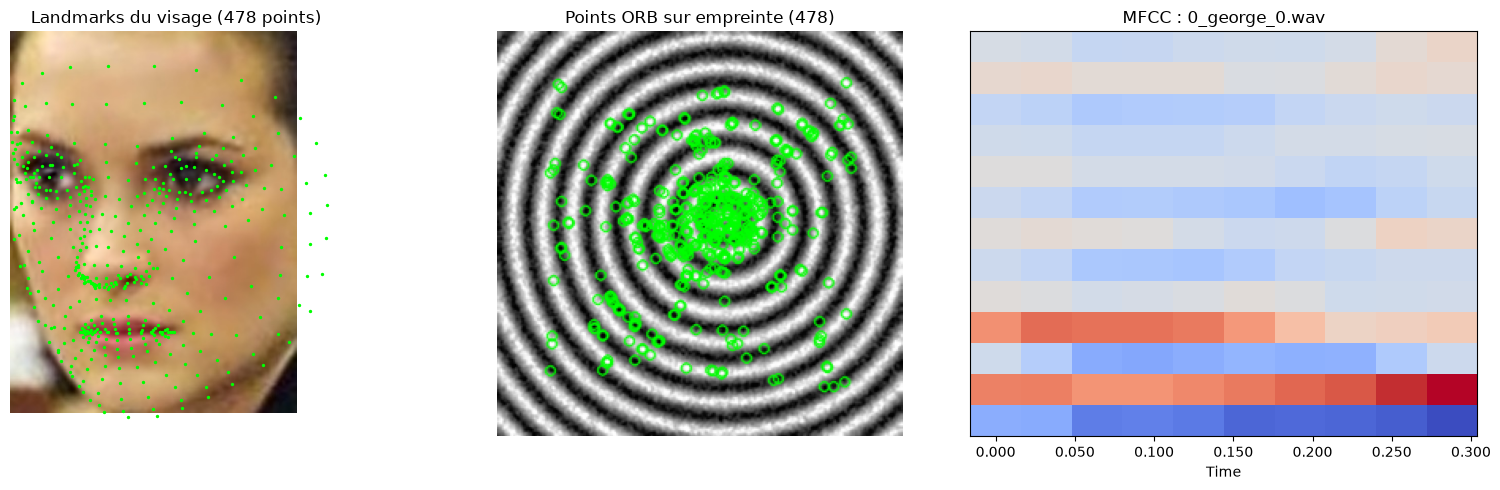

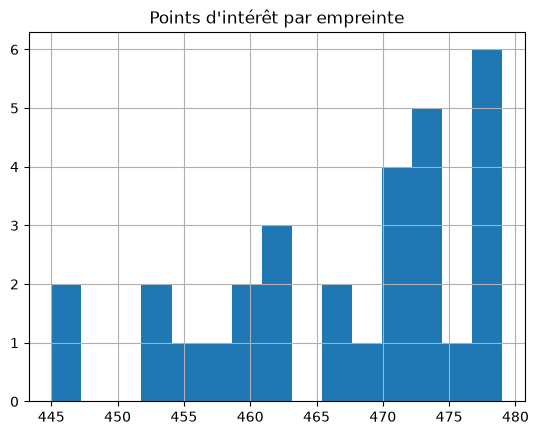

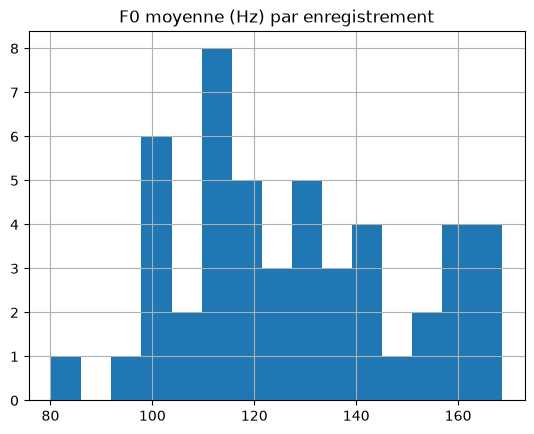

In [5]:
for name, d in [("faces", df_faces), ("fingerprint", df_fp), ("voices", df_voices)]:
    print(f"{name:12s} lignes={d.shape[0]:3d} colonnes={d.shape[1]:3d} erreurs={(d['status'] != 'ok').sum()}")
print(os.listdir(OUT))

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
if example_face is not None:                                  # landmarks sur un visage
    rgb, lm = example_face
    ax[0].imshow(rgb); ax[0].scatter(lm[:, 0], lm[:, 1], s=2, c="lime")
    ax[0].set_title("Landmarks du visage (478 points)")
if example_fp is not None:                                    # points d'intérêt sur une empreinte
    img, kps = example_fp
    ax[1].imshow(cv2.drawKeypoints(img, kps, None, color=(0, 255, 0)))
    ax[1].set_title(f"Points ORB sur empreinte ({len(kps)})")
if example_voice is not None:                                 # MFCC d'une voix
    mfcc, sr, fname = example_voice
    librosa.display.specshow(mfcc, x_axis="time", sr=sr, ax=ax[2])
    ax[2].set_title(f"MFCC : {fname}")
for a in ax[:2]:
    a.axis("off")
plt.tight_layout(); plt.show()

df_fp["n_keypoints"].hist(bins=15); plt.title("Points d'intérêt par empreinte"); plt.show()
df_voices["f0_mean"].hist(bins=15); plt.title("F0 moyenne (Hz) par enregistrement"); plt.show()

In [6]:
for name, d in [("faces", df_faces), ("fingerprint", df_fp), ("voices", df_voices)]:
    n, ok = len(d), (d["status"] == "ok").sum()
    print(f"{name}: {ok}/{n} réussis ({100*ok/n:.0f} %), colonnes = {d.shape[1]}")
print("\nVisages :\n", df_faces[["iod_px", "mouth_width", "face_height"]].describe().round(3))
print("\nEmpreintes :\n", df_fp[["n_keypoints", "contrast_std"]].describe().round(4))
print("\nVoix :\n", df_voices[["duration_s", "f0_mean"]].describe().round(2))
print("F0 manquantes :", df_voices["f0_mean"].isna().sum())
for f in ("faces", "fingerprint", "voices"):
    p = f"{OUT}/features_{f}.csv"
    print(p, round(os.path.getsize(p) / 1024, 1), "Ko")

faces: 40/40 réussis (100 %), colonnes = 28
fingerprint: 30/30 réussis (100 %), colonnes = 12
voices: 60/60 réussis (100 %), colonnes = 35

Visages :
         iod_px  mouth_width  face_height
count   40.000       40.000       40.000
mean   176.938        0.630        1.951
std     17.908        0.085        0.115
min    154.044        0.493        1.686
25%    164.881        0.577        1.877
50%    174.459        0.603        1.976
75%    180.841        0.691        2.027
max    245.942        0.890        2.163

Empreintes :
        n_keypoints  contrast_std
count      30.0000       30.0000
mean      467.1000        0.2919
std         9.8308        0.0003
min       445.0000        0.2912
25%       460.0000        0.2917
50%       470.0000        0.2920
75%       474.0000        0.2921
max       479.0000        0.2923

Voix :
        duration_s  f0_mean
count       60.00    49.00
mean         0.38   127.58
std          0.10    22.51
min          0.22    80.16
25%          0.30   110.

## 6. Bilan, erreurs et limites
**Résultats** : 40/40 visages (28 colonnes), 30/30 empreintes (12 colonnes), 60/60 voix (35 colonnes) ; aucune erreur de traitement. CSV : 19,1 Ko, 6,0 Ko, 22,7 Ko.
**Observations** :
- Visages : `nose_x` et `nose_y` valent 0 par construction (centrage sur le nez) ; `n_landmarks` vaut toujours 478. `mouth_width` varie de 0,49 à 0,89 et `face_height` de 1,69 à 2,16.
- Empreintes : 445 à 479 points ORB par image (moyenne 467) et `contrast_std` quasi constant : jeu synthétique homogène, donc peu discriminant.
- Voix : durées de 0,22 à 0,64 s ; F0 moyenne de 80 à 169 Hz ; F0 manquante (NaN) pour 11 fichiers sur 60 (aucune trame voisée détectée) alors que le statut reste « ok ».
**Limites** : ORB ne détecte pas de vraies minuties ; empreintes synthétiques ; pas d'invariance à la rotation du visage ; recadrage serré de LFW (landmarks du contour hors image) ; FSDD = chiffres isolés à 8 kHz, 6 locuteurs ; aucune évaluation FAR/FRR.